# Data Preparation for Machine Learning using Pandas


---
# Setup & Loading the Data

We'll use a handful of libraries today, each with a specific job:

| Library | Job |
|---|---|
| **pandas** | Loading and manipulating tabular data |
| **numpy** | Numerical operations (pandas is built on top of it) |
| **matplotlib / seaborn** | Data visualization |
| **scikit-learn** | Preprocessing tools (encoding, scaling) and the train/test split |

First upload `bigmart_sales.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Optional, if running in Colab and the file isn't uploaded yet:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv("bigmart_sales.csv") # DataFrame
print("Loaded! Shape:", df.shape)
df.head(7) # Display the first 7 rows of the DataFrame (default is 5 rows)

Loaded! Shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528


### Try it — Loading the Data

1. Print the number of rows and columns separately (not as a tuple) using `.shape`.
2. Print the list of all column names using `.columns`.

In [2]:
# TODO: print rows and columns separately
n_rows = df.shape[0]
n_cols = df.shape[1]
print(f"Rows: {n_rows}, Columns: {n_cols}")

# TODO: print the column names as a list
column_names = df.columns.tolist() # tolist() converts the Index object to a regular Python list
print("Column Names:", column_names)

Rows: 8523, Columns: 12
Column Names: ['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales']


---
# Initial Exploration

Before touching anything, get a feel for what you're working with: how many rows, what types each column holds,
and whether there's anything obviously wrong (duplicate rows, unexpected data types).

- `.info()` — column names, data types, and non-null counts in one view
- `.dtypes` — just the data types
- `.nunique()` — how many distinct values each column has (helps spot ID columns vs. categories)
- `.duplicated().sum()` — counts fully duplicated rows

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [4]:
print("Unique values per column:")
print(df.nunique())
print()
print("Duplicate rows:", df.duplicated().sum())

Unique values per column:
Item_Identifier              1559
Item_Weight                   415
Item_Fat_Content                5
Item_Visibility              7880
Item_Type                      16
Item_MRP                     5938
Outlet_Identifier              10
Outlet_Establishment_Year       9
Outlet_Size                     3
Outlet_Location_Type            3
Outlet_Type                     4
Item_Outlet_Sales            3493
dtype: int64

Duplicate rows: 0


### Try it — Initial Exploration

1. Print the unique values in `Outlet_Type` using `.unique()`.
2. Print the value counts (frequency of each category) for `Item_Type` using `.value_counts()`.

In [5]:
# TODO: unique values in Outlet_Type
print("Unique Outlet_Type values:", df["Outlet_Type"].unique())
# TODO: value counts for Item_Type
print("Value Counts for Item_Type:\n",df["Item_Type"].value_counts())

Unique Outlet_Type values: <StringArray>
['Supermarket Type1', 'Supermarket Type2', 'Grocery Store',
 'Supermarket Type3']
Length: 4, dtype: str
Value Counts for Item_Type:
 Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


---
# Summarizing the Data

`.describe()` gives you the standard descriptive statistics — count, mean, std, min, quartiles, max — for every
numeric column at once. This is usually the fastest way to spot something suspicious (like a minimum of `0` where
that shouldn't be possible — we'll come back to that).

In [6]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


### Try it — Summarizing the Data

Using individual pandas methods (`.mean()`, `.median()`, `.std()`), print the mean, median, and standard deviation
of `Item_Outlet_Sales` — the column we'll eventually try to predict.

In [7]:
# TODO: mean, median, std of Item_Outlet_Sales
print("Mean:", df["Item_Outlet_Sales"].mean())
print("Median:", df["Item_Outlet_Sales"].median())
print("Std:", df["Item_Outlet_Sales"].std())

Mean: 2181.288913575032
Median: 1794.331
Std: 1706.4996157338328


---
# Data Visualization

Numbers in a table only tell you so much — plots reveal shape, skew, and outliers at a glance. Four plot types cover
most of what you need at this stage:

- **Histogram** — the distribution of a single numeric column
- **Count plot (bar chart)** — the frequency of each category in a categorical column
- **Box plot** — median, spread, and outliers of a numeric column
- **Correlation heatmap** — how strongly numeric columns move together

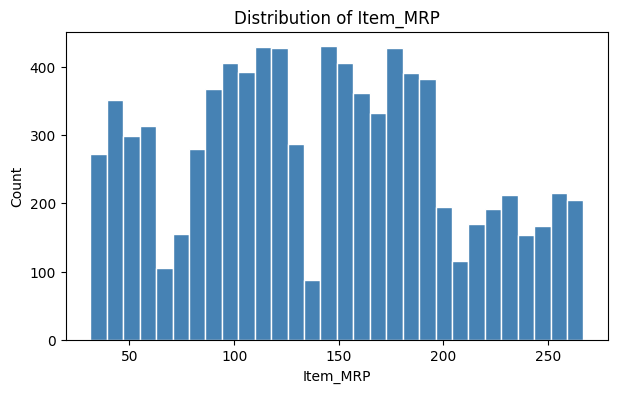

In [8]:
# Histogram: distribution of Item_MRP (item price)
plt.figure(figsize=(7, 4))
plt.hist(df['Item_MRP'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Item_MRP')
plt.xlabel('Item_MRP')
plt.ylabel('Count')
plt.show()

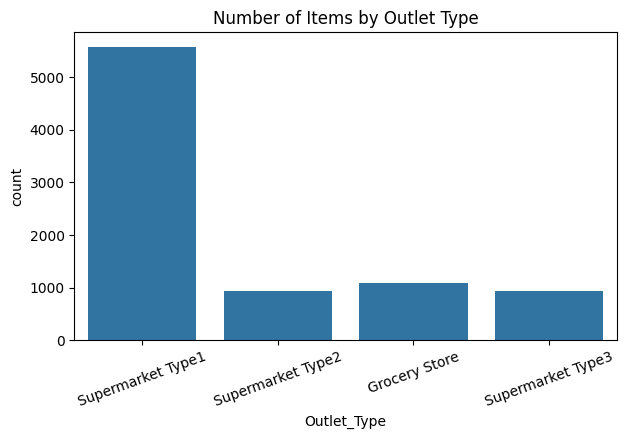

In [9]:
# Count plot: how many products come from each Outlet_Type
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Outlet_Type')
plt.title('Number of Items by Outlet Type')
plt.xticks(rotation=20)
plt.show()

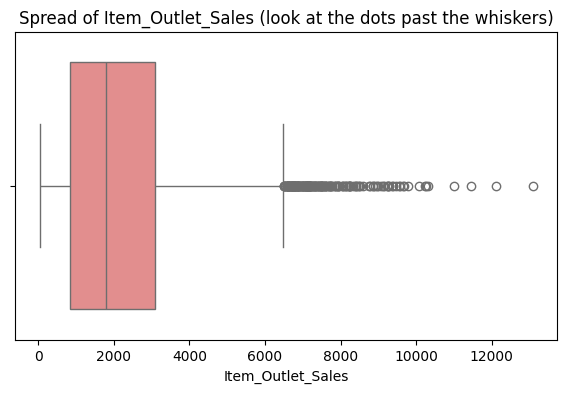

In [10]:
# Box plot: spread and outliers in Item_Outlet_Sales
plt.figure(figsize=(7, 4))
sns.boxplot(x=df['Item_Outlet_Sales'], color='lightcoral')
plt.title('Spread of Item_Outlet_Sales (look at the dots past the whiskers)')
plt.show()

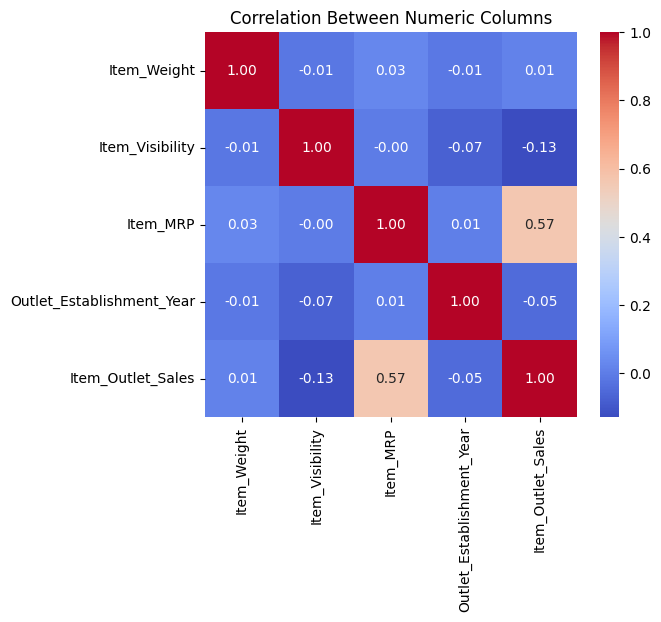

In [11]:
# Correlation heatmap: numeric columns only
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
# numeric_df.corr() computes the correlation matrix
plt.title('Correlation Between Numeric Columns')
plt.show()

### Try it — Data Visualization

Plot a histogram of `Item_Weight` (30 bins is a good default). What shape does the distribution have — is it roughly
symmetric, or skewed to one side?

Text(0.5, 1.0, 'Distribution of Item_Weight')

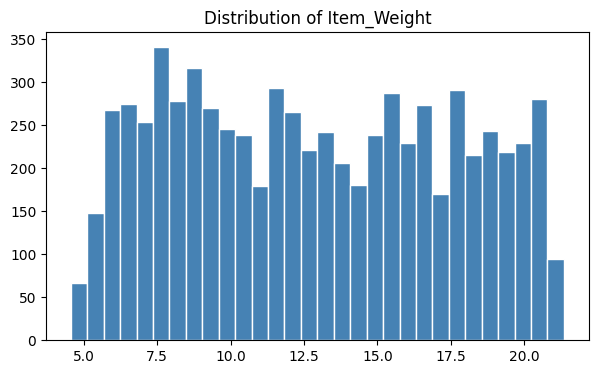

In [12]:
# TODO: histogram of Item_Weight
plt.figure(figsize=(7, 4))
plt.hist(df["Item_Weight"], bins=30, color="steelblue", edgecolor="white")
plt.title("Distribution of Item_Weight")

---
# Handling Missing Values

Most real datasets have gaps. Two columns here do: `Item_Weight` (numeric) and `Outlet_Size` (categorical) —
and each type needs a different strategy.

| Column type | Common strategy |
|---|---|
| Numeric | Fill with the **mean** or **median** (median is safer when the data is skewed or has outliers) |
| Categorical | Fill with the **mode** (the most frequent category) |
| Either | Drop the rows/column, *only* if very little data is missing |

**From here on, every Demo cell in this notebook modifies `df` directly** — this is the real cleaning pipeline.

In [13]:
print("Missing values before cleaning:")
print(df.isnull().sum())
# df.isnull() returns a boolean DataFrame indicating missing values

Missing values before cleaning:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


In [14]:
# Numeric column -> fill with the median
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].median())

# Categorical column -> fill with the mode (most frequent value)
mode_outlet_size = df['Outlet_Size'].mode()[0]
df['Outlet_Size'] = df['Outlet_Size'].fillna(mode_outlet_size)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


### Try it — Missing Values

Confirm the cleaning worked: check that `df.isnull().sum().sum()` — the *total* count of missing values across the
entire dataframe — is exactly `0`.

In [15]:
# TODO: total missing value count across the whole dataframe
total_missing = df.isnull().sum().sum()
print("Total missing values:", total_missing)

Total missing values: 0


---
# Cleaning Inconsistent & Disguised Data

Two extra problems that `.isnull().sum()` completely misses, because they're not technically "missing":

1. **Inconsistent category labels** — the same real-world category, spelled differently. Watch what happens
when we check `Item_Fat_Content`.
2. **Disguised missing values** — a value that *looks* valid but is actually a stand-in for "unknown," like a
visibility of exactly `0`. A product on a shelf can't realistically have *zero* visibility — that's almost
certainly missing data that got recorded as `0` instead of blank.

In [16]:
print("Raw Item_Fat_Content categories:")
print(df['Item_Fat_Content'].value_counts())

Raw Item_Fat_Content categories:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


In [17]:
# Standardize inconsistent labels into just two real categories
fat_content_map = {
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular',
}
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(fat_content_map)

print("Cleaned categories:")
print(df['Item_Fat_Content'].value_counts())

Cleaned categories:
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


In [18]:
# Disguised missing values: Item_Visibility == 0 isn't physically realistic
print("Rows with zero visibility:", (df['Item_Visibility'] == 0).sum())

# Treat 0 as missing, then fill using the average visibility for that item's Item_Type
# (a smarter fill than a single global average, since visibility norms differ by product type)
df['Item_Visibility'] = df['Item_Visibility'].replace(0, np.nan)
df['Item_Visibility'] = df.groupby('Item_Type')['Item_Visibility'].transform(lambda x: x.fillna(x.mean()))

print("Rows with zero/missing visibility after fix:", (df['Item_Visibility'] == 0).sum() + df['Item_Visibility'].isnull().sum())

Rows with zero visibility: 526
Rows with zero/missing visibility after fix: 0


### Try it — Inconsistent & Disguised Data

1. Confirm `Item_Fat_Content` now has exactly `2` unique values using `.nunique()`.
2. Print `df['Item_Visibility'].min()` — it should no longer be `0`.

In [19]:
# TODO: confirm 2 unique fat content categories
print('Unique values in Item_Fat_Content:', df['Item_Fat_Content'].nunique())
# TODO: print the new minimum visibility
print('Minimum Item_Visibility:', df['Item_Visibility'].min())

Unique values in Item_Fat_Content: 2
Minimum Item_Visibility: 0.003574698


---
# Feature Engineering

Feature engineering means creating **new** columns from the ones you already have, when those new columns carry
information a model couldn't easily extract on its own. Two good candidates here:

- `Item_Identifier` always starts with a 2-letter code — `FD` (Food), `DR` (Drinks), or `NC` (Non-Consumable).
  That's a real category hiding inside an ID string.
- `Outlet_Establishment_Year` is a year, but what usually matters for sales is **how old** the outlet is, not
  the specific calendar year. (This dataset is understood to be from 2013, so we'll use that as our reference year.)

In [20]:
# Extract a category from the first 2 characters of the item ID
prefix_map = {'FD': 'Food', 'DR': 'Drinks', 'NC': 'Non-Consumable'}
df['Item_Category'] = df['Item_Identifier'].str[:2].map(prefix_map)
print(df['Item_Category'].value_counts())

Item_Category
Food              6125
Non-Consumable    1599
Drinks             799
Name: count, dtype: int64


In [21]:
# Convert establishment year into outlet age (reference year: 2013)
df['Outlet_Age'] = 2013 - df['Outlet_Establishment_Year']
df[['Outlet_Establishment_Year', 'Outlet_Age']].drop_duplicates().sort_values('Outlet_Age')

,Outlet_Establishment_Year,Outlet_Age
1,2009,4
9,2007,6
19,2004,9
8,2002,11
0,1999,14
3,1998,15
11,1997,16
4,1987,26
7,1985,28


### Try it — Feature Engineering

Create a new column `Item_MRP_Level` that bins `Item_MRP` into 4 equal-sized groups (quartiles), using
`pd.qcut(df['Item_MRP'], 4, labels=['Low', 'Medium', 'High', 'Very High'])`. Print the resulting value counts.

In [22]:
# TODO: create the binned column
df['Item_MRP_Level'] = pd.qcut(df['Item_MRP'], 4, labels=['Low', 'Medium', 'High', 'Very High'])
print(df['Item_MRP_Level'].value_counts())

Item_MRP_Level
Low          2131
Medium       2131
Very High    2131
High         2130
Name: count, dtype: int64


---
# Outlier Detection

An **outlier** is a value far outside the normal range for that column. The most common rule of thumb is the
**IQR method**: anything below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` (where IQR = Q3 - Q1) is flagged.

Outliers aren't automatically wrong — sometimes they're genuine, important data points (a real bestseller item,
for instance). The right response is usually to **investigate first, and only remove or cap them if you have good
reason to** — which is why we'll detect them here without automatically deleting anything.

In [23]:
Q1 = df['Item_Visibility'].quantile(0.25)
Q3 = df['Item_Visibility'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Item_Visibility'] < lower_bound) | (df['Item_Visibility'] > upper_bound)]
print(f"Bounds: [{lower_bound:.4f}, {upper_bound:.4f}]")
print(f"Number of outlier rows in Item_Visibility: {len(outliers)}")

Bounds: [-0.0592, 0.1868]
Number of outlier rows in Item_Visibility: 173


### Try it — Outlier Detection

Using the same IQR method, compute the lower and upper bounds for `Item_Outlet_Sales` (our target column),
and count how many rows fall outside them.

In [24]:
# TODO: IQR bounds for Item_Outlet_Sales
Q1_sales = df['Item_Outlet_Sales'].quantile(0.25)
Q3_sales = df['Item_Outlet_Sales'].quantile(0.75)
IQR_sales = Q3_sales - Q1_sales
lower_sales = Q1_sales - 1.5 * IQR_sales
upper_sales = Q3_sales + 1.5 * IQR_sales

sales_outliers = df[(df['Item_Outlet_Sales'] < lower_sales) | (df['Item_Outlet_Sales'] > upper_sales)]
print("Number of outlier rows in Item_Outlet_Sales:", len(sales_outliers))

Number of outlier rows in Item_Outlet_Sales: 186


---
# Encoding Categorical Data

ML models need numbers, not text — so every categorical column has to be converted before modeling. There are two
main approaches, and picking the right one matters:

| Type | Example column | Technique |
|---|---|---|
| **Ordinal** (categories have a natural order) | `Outlet_Size`: Small < Medium < High | Map to integers by hand, preserving the order |
| **Nominal** (no natural order) | `Outlet_Type`, `Item_Fat_Content`, `Item_Category` | **One-hot encoding** — a new 0/1 column per category |

Using plain integers (0, 1, 2, 3...) for a *nominal* column would trick the model into thinking one category is
"greater than" another, which isn't true — that's why nominal columns get one-hot encoded instead.

In [25]:
# Ordinal encoding: Outlet_Size has a natural small-to-large order
size_map = {'Small': 0, 'Medium': 1, 'High': 2}
df['Outlet_Size_Encoded'] = df['Outlet_Size'].map(size_map)
df[['Outlet_Size', 'Outlet_Size_Encoded']].drop_duplicates()

,Outlet_Size,Outlet_Size_Encoded
0,Medium,1
4,High,2
11,Small,0


In [26]:
# One-hot encoding: nominal columns -> pd.get_dummies()
nominal_cols = ['Item_Fat_Content', 'Outlet_Type', 'Outlet_Location_Type', 'Item_Category']
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# drop_first=True avoids redundant columns (e.g. if Fat_Content isn't 'Regular', it must be 'Low Fat')
new_cols = [c for c in df_encoded.columns if c not in df.columns]
print("New one-hot columns created:", new_cols)

New one-hot columns created: ['Item_Fat_Content_Regular', 'Outlet_Type_Supermarket Type1', 'Outlet_Type_Supermarket Type2', 'Outlet_Type_Supermarket Type3', 'Outlet_Location_Type_Tier 2', 'Outlet_Location_Type_Tier 3', 'Item_Category_Food', 'Item_Category_Non-Consumable']


### Try it — Encoding

One-hot encode `Item_Type` on its own (16 categories) into a separate variable `item_type_dummies` using
`pd.get_dummies(df['Item_Type'], prefix='ItemType')`, and print its shape. This is a good example of a
**high-cardinality** categorical column — one with many categories — where one-hot encoding creates a lot of new columns;
in practice this is a trade-off worth thinking about rather than doing automatically.

In [27]:
# TODO: one-hot encode Item_Type into its own variable
item_type_dummies = pd.get_dummies(df['Item_Type'], prefix='ItemType')

print("Shape:", item_type_dummies.shape)

Shape: (8523, 16)


---
# Feature Scaling

`Item_MRP` ranges into the hundreds, while `Item_Visibility` is a small fraction — many ML algorithms are sensitive
to features being on wildly different scales, and will implicitly treat the bigger-magnitude column as "more important"
even when it isn't. **Scaling** puts every numeric column on a comparable range.

| Scaler | What it does | When to use |
|---|---|---|
| `StandardScaler` | Rescales to mean `0`, std `1` | The default choice for most models |
| `MinMaxScaler` | Rescales to a fixed range, usually `[0, 1]` | When you need bounded values, e.g. for neural networks |

In [28]:
numeric_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']

scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

df_encoded[numeric_cols].describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Age
count,8.523000e+03,8.523000e+03,8.523000e+03,8.523000e+03
mean,2.234254e-16,9.712335e-17,-1.604828e-16,-7.753194e-17
std,1.000059e+00,1.000059e+00,1.000059e+00,1.000059e+00
min,-1.953734e+00,-1.372761e+00,-1.761688e+00,-1.334103e+00
25%,-8.288209e-01,-7.673087e-01,-7.574307e-01,-7.368218e-01
50%,-5.048970e-02,-1.764772e-01,3.243893e-02,-1.395408e-01
75%,7.538647e-01,4.944489e-01,7.170372e-01,1.293934e+00
max,2.019540e+00,5.291299e+00,2.021724e+00,1.532846e+00


### Try it — Feature Scaling

Using a **fresh copy** of the original numeric columns (so we don't disturb the pipeline), apply `MinMaxScaler`
instead and compare the resulting min/max to StandardScaler's mean/std above.

In [29]:
numeric_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']
df_minmax = df[numeric_cols].copy()

# TODO: apply MinMaxScaler
minmax_scaler = MinMaxScaler()
df_minmax[numeric_cols] = minmax_scaler.fit_transform(df_minmax[numeric_cols])

df_minmax.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Age
count,8523.000000,8523.000000,8523.000000,8523.000000
mean,0.491719,0.205995,0.465635,0.465339
std,0.251696,0.150067,0.264327,0.348823
min,0.000000,0.000000,0.000000,0.000000
25%,0.283120,0.090853,0.265437,0.208333
50%,0.479012,0.179513,0.474209,0.416667
75%,0.681453,0.280191,0.655156,0.916667
max,1.000000,1.000000,1.000000,1.000000


---
# Train-Test Split

Remember step 4 of the ML workflow from Day 1: before training any model, hold out a portion of the data it will
never see, so you can honestly evaluate it afterward. `train_test_split` does this with one line — and shuffles the
data first, so the split isn't biased by row order.

In [30]:
# Build the final modeling table: drop ID/text columns that aren't useful as model inputs
drop_cols = ['Item_Identifier', 'Outlet_Identifier', 'Item_Type', 'Outlet_Size',
             'Outlet_Establishment_Year']
df_model = df_encoded.drop(columns=drop_cols)

X = df_model.drop(columns=['Item_Outlet_Sales'])
y = df_model['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (6818, 14)
X_test:  (1705, 14)
y_train: (6818,)
y_test:  (1705,)


### Try it — Train-Test Split

Redo the split with `test_size=0.3` instead of `0.2` (keep `random_state=42`), storing the results in new variables
`X_train30`, `X_test30`, `y_train30`, `y_test30`. Print all four shapes — how much bigger is the test set now?

In [31]:
# TODO: split with test_size=0.3
X_train30, X_test30, y_train30, y_test30 = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train30.shape, X_test30.shape, y_train30.shape, y_test30.shape)

(5966, 14) (2557, 14) (5966,) (2557,)


---
# Saving the Prepared Data & Wrap-up

The whole point of today's work is to hand off a clean, model-ready dataset — so let's save it.

In [32]:
df_model.to_csv("bigmart_sales_cleaned.csv", index=False)
print("Saved bigmart_sales_cleaned.csv —", df_model.shape)

Saved bigmart_sales_cleaned.csv — (8523, 15)


## Combining DataFrames (Databases) in Pandas

Let's create two sample DataFrames to illustrate `pd.concat()` and `pd.merge()`.

In [33]:
import pandas as pd

# Sample DataFrame 1
df_a = pd.DataFrame({
    'ID': [1, 2, 3, 4],
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Age': [25, 30, 35, 40]
})

# Sample DataFrame 2
df_b = pd.DataFrame({
    'ID': [5, 6, 7, 8],
    'Name': ['Eve', 'Frank', 'Grace', 'Heidi'],
    'Age': [22, 28, 33, 38]
})

print("DataFrame df_a:")
display(df_a)

print("\nDataFrame df_b:")
display(df_b)

DataFrame df_a:


,ID,Name,Age
0,1,Alice,25
1,2,Bob,30
2,3,Charlie,35
3,4,David,40



DataFrame df_b:


,ID,Name,Age
0,5,Eve,22
1,6,Frank,28
2,7,Grace,33
3,8,Heidi,38


### Using `pd.concat()` to stack DataFrames (add rows)

This is useful when you have data with the same columns that you want to combine vertically.

In [34]:
# Concatenate df_a and df_b vertically
df_combined_rows = pd.concat([df_a, df_b], ignore_index=True)

print("Combined DataFrame using pd.concat (rows):")
display(df_combined_rows)

Combined DataFrame using pd.concat (rows):


,ID,Name,Age
0,1,Alice,25
1,2,Bob,30
2,3,Charlie,35
3,4,David,40
4,5,Eve,22
5,6,Frank,28
6,7,Grace,33
7,8,Heidi,38


### Using `pd.merge()` to combine DataFrames based on a common key (add columns)

This is similar to a SQL JOIN. We'll create another DataFrame with a common `ID` column to demonstrate.

In [35]:
# Sample DataFrame 3 for merging
df_c = pd.DataFrame({
    'ID': [1, 2, 3, 9],
    'City': ['New York', 'Los Angeles', 'Chicago', 'Houston'],
    'Occupation': ['Engineer', 'Artist', 'Doctor', 'Scientist']
})

print("DataFrame df_c:")
display(df_c)

# Merge df_a with df_c on the 'ID' column (inner merge by default)
df_merged_inner = pd.merge(df_a, df_c, on='ID', how='inner')

print("\nCombined DataFrame using pd.merge (inner join on ID):")
display(df_merged_inner)

# Example of a left merge: keeps all rows from df_a and matches from df_c
df_merged_left = pd.merge(df_a, df_c, on='ID', how='left')

print("\nCombined DataFrame using pd.merge (left join on ID):")
display(df_merged_left)

DataFrame df_c:


,ID,City,Occupation
0,1,New York,Engineer
1,2,Los Angeles,Artist
2,3,Chicago,Doctor
3,9,Houston,Scientist



Combined DataFrame using pd.merge (inner join on ID):


,ID,Name,Age,City,Occupation
0,1,Alice,25,New York,Engineer
1,2,Bob,30,Los Angeles,Artist
2,3,Charlie,35,Chicago,Doctor



Combined DataFrame using pd.merge (left join on ID):


,ID,Name,Age,City,Occupation
0,1,Alice,25,New York,Engineer
1,2,Bob,30,Los Angeles,Artist
2,3,Charlie,35,Chicago,Doctor
3,4,David,40,NaN,NaN


### Using `df.join()` to combine DataFrames (based on index)

`df.join()` is a convenient method for combining DataFrames, primarily by matching their indices. It's particularly useful when one of the DataFrames has meaningful information stored in its index, or when you want to combine on an index-to-column or index-to-index basis.

Let's create another DataFrame to demonstrate `df.join()`. We'll set its index to match the `ID` column from `df_a` to show a common use case.

In [36]:
# Sample DataFrame 4 for joining (with ID as index)
df_d = pd.DataFrame({
    'Fav_Color': ['Blue', 'Green', 'Red', 'Yellow'],
    'Score': [85, 90, 78, 92]
}, index=[1, 2, 3, 4]) # Set index to match IDs in df_a

print("DataFrame df_d (indexed by ID):")
display(df_d)

# Join df_a with df_d on index
df_joined = df_a.join(df_d, on='ID')

print("\nCombined DataFrame using df.join (on ID column of df_a with index of df_d):")
display(df_joined)

# You can also join two DataFrames on their indices directly:
df_e = pd.DataFrame({
    'Product': ['ItemA', 'ItemB', 'ItemC']
}, index=['Alice', 'Bob', 'Charlie'])

df_f = pd.DataFrame({
    'Price': [10, 20, 15]
}, index=['Alice', 'Bob', 'David'])

print("\nDataFrame df_e (indexed by Name):")
display(df_e)
print("\nDataFrame df_f (indexed by Name):")
display(df_f)

df_index_joined = df_e.join(df_f, how='left')
print("\nCombined DataFrame using df.join (left join on index):")
display(df_index_joined)

DataFrame df_d (indexed by ID):


,Fav_Color,Score
1,Blue,85
2,Green,90
3,Red,78
4,Yellow,92



Combined DataFrame using df.join (on ID column of df_a with index of df_d):


,ID,Name,Age,Fav_Color,Score
0,1,Alice,25,Blue,85
1,2,Bob,30,Green,90
2,3,Charlie,35,Red,78
3,4,David,40,Yellow,92



DataFrame df_e (indexed by Name):


,Product
Alice,ItemA
Bob,ItemB
Charlie,ItemC



DataFrame df_f (indexed by Name):


,Price
Alice,10
Bob,20
David,15



Combined DataFrame using df.join (left join on index):


,Product,Price
Alice,ItemA,10.0
Bob,ItemB,20.0
Charlie,ItemC,NaN
